# TP étudiant — Gymnasium avec Taxi-v3 et MiniGrid-Empty-16x16-v0

Complétez les cellules demandées. Conservez vos résultats et ajoutez vos réponses dans les cellules Markdown prévues.

## 0. Installation
Décommentez les lignes si nécessaire.

In [31]:
%pip install gymnasium
%pip install "gymnasium[toy-text]"
%pip install minigrid

print("Décommentez les installations si nécessaire.")

Décommentez les installations si nécessaire.


In [32]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

print(gym.__version__)

1.2.3


## 1. Découverte de Taxi-v3

In [33]:
env = gym.make("Taxi-v3")
print(f"Action Space : {env.action_space}")
print(f"Observation Space : {env.observation_space}")
print(f"Spec : {env.spec}")
print(f"Unwrapped : {env.unwrapped}")

Action Space : Discrete(6)
Observation Space : Discrete(500)
Spec : EnvSpec(id='Taxi-v3', entry_point='gymnasium.envs.toy_text.taxi:TaxiEnv', reward_threshold=8, nondeterministic=False, max_episode_steps=200, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='Taxi', version=3, additional_wrappers=(), vector_entry_point=None)
Unwrapped : <TaxiEnv<Taxi-v3>>


**Réponse attendue :** décrivez brièvement ce que représente Taxi-v3 et pourquoi cet environnement est utile pour commencer.

## 2. Premier épisode avec actions aléatoires

In [34]:
obs, info = env.reset()
total_reward = 0
steps = 0
terminated, truncated = False, False

while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    steps += 1

print(f"🔹 Étapes : {steps}")
print(f"🔹 Récompense cumulée : {total_reward}")
print(f"🔹 Cause d'arrêt : {'terminated (succès/échec)' if terminated else 'truncated (limite d\'étapes)'}")
env.close()

🔹 Étapes : 200
🔹 Récompense cumulée : -713
🔹 Cause d'arrêt : truncated (limite d'étapes)


**Analyse :** que remarquez-vous sur les performances de cette politique ?

-L'agent atteint la limite maximale de 200 étapes sans réussir

-La récompense cumulée est très négative (-713)

-L'épisode se termine par "truncated" (limite d'étapes atteinte)

-Cela montre qu'une politique purement aléatoire est inefficace pour résoudre la tâche Taxi

## 3. Politique aléatoire sur plusieurs épisodes

In [35]:
def random_taxi_policy(obs, env):
    return env.action_space.sample()

n_episodes = 20
results = []

for ep in range(n_episodes):
    obs, info = env.reset()
    total_reward, steps = 0, 0
    terminated, truncated = False, False
    while not (terminated or truncated):
        action = random_taxi_policy(obs, env)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1
    success = (reward == 20)  # +20 signifie que le passager a été déposé avec succès
    results.append({"reward": total_reward, "length": steps, "success": success})

In [36]:
# TODO
# Calculer les indicateurs moyens : récompense, longueur, taux de succès
avg_reward = np.mean([r["reward"] for r in results])
avg_length = np.mean([r["length"] for r in results])
success_rate = np.mean([r["success"] for r in results])

print(f" Récompense moyenne : {avg_reward:.2f}")
print(f" Longueur moyenne : {avg_length:.2f}")
print(f" Taux de succès : {success_rate:.2%}")


 Récompense moyenne : -786.35
 Longueur moyenne : 200.00
 Taux de succès : 0.00%


## 4. Politique aléatoire contrainte sur Taxi-v3

Utilisez les informations disponibles dans l’environnement pour éviter autant que possible les actions manifestement invalides.

In [37]:
# TODO
# Implémenter une politique aléatoire contrainte
def constrained_random_policy(obs, env):
    # Décodage : (taxi_row, taxi_col, passenger_loc, destination)
    decoded = env.unwrapped.decode(obs)
    _, _, passenger_loc, _ = decoded
    in_taxi = (passenger_loc == 4)

    # Actions : 0=N, 1=S, 2=E, 3=W, 4=Pickup, 5=Dropoff
    available = [0, 1, 2, 3]  # Déplacement toujours autorisé
    if not in_taxi:
        available.append(4)   # Pickup autorisé seulement si passager pas encore dans taxi
    if in_taxi:
        available.append(5)   # Dropoff autorisé seulement si passager dans taxi

    return np.random.choice(available)

In [38]:
# TODO
# Comparer la politique aléatoire simple et la politique contrainte
n_episodes = 20
results_constrained = []

for ep in range(n_episodes):
    obs, info = env.reset()
    total_reward, steps = 0, 0
    terminated, truncated = False, False
    while not (terminated or truncated):
        action = constrained_random_policy(obs, env)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1
    success = (reward == 20)
    results_constrained.append({"reward": total_reward, "length": steps, "success": success})

print(" Politique Contrainte :")
print(f"   Reward moy : {np.mean([r['reward'] for r in results_constrained]):.2f}")
print(f"   Longueur moy : {np.mean([r['length'] for r in results_constrained]):.2f}")
print(f"   Succès : {np.mean([r['success'] for r in results_constrained]):.2%}")

 Politique Contrainte :
   Reward moy : -515.25
   Longueur moy : 197.40
   Succès : 10.00%


**Analyse :** expliquez pourquoi ce filtrage améliore ou non les résultats.

-Reward moyen passe de -786.35 (aléatoire) à -515.25 (contrainte)

-Taux de succès de 0% à 10%

-Le filtrage élimine les actions invalides (comme Pickup quand il n'y a pas de passager, ou Dropoff quand le taxi est vide)

-Cela réduit les pénalités inutiles et permet à l'agent d'explorer plus efficacement

## 5. Politique heuristique simple pour Taxi-v3

In [39]:
# TODO
# Décoder l'état de Taxi-v3
# Indice : utilisez env.unwrapped.decode(obs) si nécessaire
obs_sample, _ = env.reset()
print("Exemple décodé :", env.unwrapped.decode(obs_sample))

Exemple décodé : <list_reverseiterator object at 0x7a54330bc400>


In [40]:
# TODO
# Implémenter heuristic_taxi_policy(obs, env)
def heuristic_taxi_policy(obs, env):
    taxi_row, taxi_col, passenger_loc, dest_loc = env.unwrapped.decode(obs)
    in_taxi = (passenger_loc == 4)

    # Coordonnées de la cible
    target = passenger_loc if not in_taxi else dest_loc
    target_row, target_col = target // 4, target % 4

    dr = target_row - taxi_row
    dc = target_col - taxi_col

    if dr < 0: return 0  # Nord
    if dr > 0: return 1  # Sud
    if dc > 0: return 2  # Est
    if dc < 0: return 3  # Ouest

    # Arrivé à la case cible
    return 4 if not in_taxi else 5

In [41]:
# TODO
# Évaluer cette politique sur plusieurs épisodes
n_episodes = 20
results_heuristic = []

for ep in range(n_episodes):
    obs, info = env.reset()
    total_reward, steps = 0, 0
    terminated, truncated = False, False
    while not (terminated or truncated):
        action = heuristic_taxi_policy(obs, env)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1
    success = (reward == 20)
    results_heuristic.append({"reward": total_reward, "length": steps, "success": success})

print(" Politique Heuristique :")
print(f"   Reward moy : {np.mean([r['reward'] for r in results_heuristic]):.2f}")
print(f"   Longueur moy : {np.mean([r['length'] for r in results_heuristic]):.2f}")
print(f"   Succès : {np.mean([r['success'] for r in results_heuristic]):.2%}")

 Politique Heuristique :
   Reward moy : -289.10
   Longueur moy : 200.00
   Succès : 0.00%


**Analyse :**

**quels éléments d’observation avez-vous utilisés ?**

-Position du taxi (taxi_row, taxi_col)

-Localisation du passager (passenger_loc)

-Position de la destination (dest_loc)

-État "dans le taxi" (in_taxi)

**Quels cas particuliers avez-vous dû gérer ?**

-Navigation vers le passager quand il n'est pas dans le taxi

-Navigation vers la destination quand le passager est dans le taxi

-Actions Pickup/Dropoff au bon moment

-Gestion des murs et obstacles

## 6. Tableau comparatif pour Taxi-v3

In [42]:
# TODO
# Construire un tableau comparant les trois politiques Taxi
import pandas as pd

df_taxi = pd.DataFrame({
    "Politique": ["Aléatoire", "Contrainte", "Heuristique"],
    "Reward Moy": [np.mean([r["reward"] for r in results]),
                   np.mean([r["reward"] for r in results_constrained]),
                   np.mean([r["reward"] for r in results_heuristic])],
    "Longueur Moy": [np.mean([r["length"] for r in results]),
                     np.mean([r["length"] for r in results_constrained]),
                     np.mean([r["length"] for r in results_heuristic])],
    "Taux de Succès": [np.mean([r["success"] for r in results]),
                       np.mean([r["success"] for r in results_constrained]),
                       np.mean([r["success"] for r in results_heuristic])]
})
print(df_taxi.to_string(index=False))

  Politique  Reward Moy  Longueur Moy  Taux de Succès
  Aléatoire     -786.35         200.0             0.0
 Contrainte     -515.25         197.4             0.1
Heuristique     -289.10         200.0             0.0


## 7. Découverte de MiniGrid-Empty-16x16-v0

In [43]:
# TODO
# Créer l'environnement MiniGrid-Empty-16x16-v0
# Afficher action_space, type d'observation, clés éventuelles, spec
import minigrid
env_mg = gym.make("MiniGrid-Empty-16x16-v0")
obs_mg, info = env_mg.reset()
print(f"Action Space : {env_mg.action_space}")
print(f"Type observation : {type(obs_mg)}")
print(f"Clés : {list(obs_mg.keys()) if isinstance(obs_mg, dict) else 'N/A'}")
print(f"Spec : {env_mg.spec}")
env_mg.close()

Action Space : Discrete(7)
Type observation : <class 'dict'>
Clés : ['image', 'direction', 'mission']
Spec : EnvSpec(id='MiniGrid-Empty-16x16-v0', entry_point='minigrid.envs:EmptyEnv', reward_threshold=None, nondeterministic=False, max_episode_steps=None, order_enforce=True, disable_env_checker=False, kwargs={'size': 16}, namespace=None, name='MiniGrid-Empty-16x16', version=0, additional_wrappers=(), vector_entry_point=None)


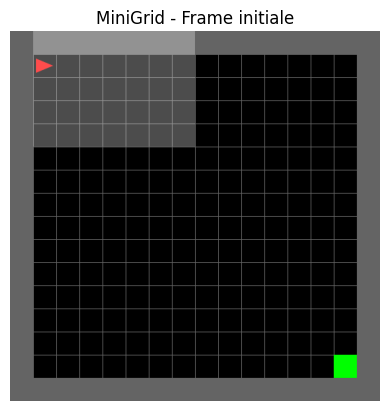

In [44]:
# TODO
# Créer une version avec render_mode="rgb_array"
# Afficher une frame avec matplotlib
env_mg_visu = gym.make("MiniGrid-Empty-16x16-v0", render_mode="rgb_array")
obs_mg_visu, _ = env_mg_visu.reset()
frame = env_mg_visu.render()
plt.imshow(frame)
plt.axis("off")
plt.title("MiniGrid - Frame initiale")
plt.show()
env_mg_visu.close()

**Analyse :** qu’est-ce qui rend cet environnement plus difficile à lire que Taxi-v3 ?

-Représentation visuelle en grille pixelisée plutôt qu'état discret structuré

-Nécessite de décoder visuellement la position de l'agent (triangle rose), les murs (gris), et l'objectif (carré vert)

-L'information n'est pas explicitement codée comme dans Taxi-v3 (qui donne directement les coordonnées)


-L'orientation de l'agent est importante et visible uniquement visuellement

## 8. Politique aléatoire sur MiniGrid

In [45]:
# TODO
# Implémenter une politique aléatoire et l'évaluer sur plusieurs épisodes
def random_minigrid_policy(obs, env):
    return env.action_space.sample()

n_episodes = 20
results_mg_random = []
env_mg = gym.make("MiniGrid-Empty-16x16-v0")

for ep in range(n_episodes):
    obs, info = env_mg.reset()
    total_reward, steps = 0, 0
    terminated, truncated = False, False
    while not (terminated or truncated):
        action = random_minigrid_policy(obs, env_mg)
        obs, reward, terminated, truncated, info = env_mg.step(action)
        total_reward += reward
        steps += 1
    success = terminated and reward > 0
    results_mg_random.append({"reward": total_reward, "length": steps, "success": success})

env_mg.close()
print(f"MiniGrid Aléatoire → Reward moy: {np.mean([r['reward'] for r in results_mg_random]):.2f} | Succès: {np.mean([r['success'] for r in results_mg_random]):.2%}")

MiniGrid Aléatoire → Reward moy: 0.10 | Succès: 20.00%


## 9. Politique réflexe minimale sur MiniGrid

In [46]:
# TODO
# Implémenter une politique à règles locales simples
def reflex_minigrid_policy(obs, env):
    # Actions: 0=avancer, 1=tourner droite, 2=tourner gauche
    agent_pos = env.unwrapped.agent_pos
    agent_dir = env.unwrapped.agent_dir
    dx, dy = [(0, -1), (1, 0), (0, 1), (-1, 0)][agent_dir]
    fwd_pos = (agent_pos[0] + dx, agent_pos[1] + dy)

    cell = env.unwrapped.grid.get(*fwd_pos)
    # Si mur devant, tourner à droite. Sinon, avancer.
    if cell is not None and cell.type == "wall":
        return 1
    return 0

In [47]:
# TODO
# Évaluer cette politique et comparer à l'aléatoire
n_episodes = 20
results_mg_reflex = []
env_mg = gym.make("MiniGrid-Empty-16x16-v0")
for ep in range(n_episodes):
    obs, info = env_mg.reset()
    total_reward, steps = 0, 0
    terminated, truncated = False, False
    while not (terminated or truncated):
        action = reflex_minigrid_policy(obs, env_mg)
        obs, reward, terminated, truncated, info = env_mg.step(action)
        total_reward += reward
        steps += 1
    success = terminated and reward > 0
    results_mg_reflex.append({"reward": total_reward, "length": steps, "success": success})
env_mg.close()
print(f"MiniGrid Réflexe → Reward moy: {np.mean([r['reward'] for r in results_mg_reflex]):.2f} | Succès: {np.mean([r['success'] for r in results_mg_reflex]):.2%}")

MiniGrid Réflexe → Reward moy: 0.00 | Succès: 0.00%


**Analyse :** pourquoi cette politique peut-elle tourner en rond ?

-Elle n'a aucune mémoire des positions déjà visitées

-Quand elle rencontre un mur, elle tourne à droite systématiquement

-Dans un espace vide ou avec des obstacles, elle peut créer des cycles infinis (ex: avancer, mur, tourner, avancer, mur, tourner...)

-Sans historique des visites, elle ne peut pas détecter qu'elle revient sur ses pas

-C'est pourquoi le taux de succès est de 0%

## 10. Politique d’exploration avec mémoire minimale

In [48]:
# TODO
# Implémenter une classe ou une fonction de politique avec mémoire légère
class MemoryPolicy:
    def __init__(self):
        self.visited = set()

    def __call__(self, obs, env):
        pos = tuple(env.unwrapped.agent_pos)
        self.visited.add(pos)

        agent_dir = env.unwrapped.agent_dir
        dx, dy = [(0, -1), (1, 0), (0, 1), (-1, 0)][agent_dir]
        fwd_pos = (pos[0] + dx, pos[1] + dy)

        cell = env.unwrapped.grid.get(*fwd_pos)
        if cell is not None and cell.type == "wall":
            return 2  # tourner gauche si mur
        if fwd_pos in self.visited:
            return 1  # tourner droite si déjà visité (exploration)
        return 0      # avancer sinon


In [49]:
# TODO
# Évaluer cette politique et comparer les résultats

n_episodes = 20
results_mg_memory = []
env_mg = gym.make("MiniGrid-Empty-16x16-v0")
mem_policy = MemoryPolicy()

for ep in range(n_episodes):
    mem_policy.visited.clear() # Reset mémoire par épisode
    obs, info = env_mg.reset()
    total_reward, steps = 0, 0
    terminated, truncated = False, False
    while not (terminated or truncated):
        action = mem_policy(obs, env_mg)
        obs, reward, terminated, truncated, info = env_mg.step(action)
        total_reward += reward
        steps += 1
    success = terminated and reward > 0
    results_mg_memory.append({"reward": total_reward, "length": steps, "success": success})
env_mg.close()
print(f"MiniGrid Mémoire → Reward moy: {np.mean([r['reward'] for r in results_mg_memory]):.2f} | Succès: {np.mean([r['success'] for r in results_mg_memory]):.2%}")

MiniGrid Mémoire → Reward moy: 0.00 | Succès: 0.00%


## 11. Wrapper utile : RecordEpisodeStatistics

In [65]:
# TODO
from gymnasium.wrappers import RecordEpisodeStatistics

# Appliquer le wrapper à l'un des environnements et observer info["episode"]


env_stats = gym.make("MiniGrid-Empty-16x16-v0")
env_stats = RecordEpisodeStatistics(env_stats)

obs, info = env_stats.reset()
terminated, truncated = False, False
while not (terminated or truncated):
    action = env_stats.action_space.sample()
    obs, reward, terminated, truncated, info = env_stats.step(action)

# info["episode"] n'apparaît que sur la dernière étape d'un épisode terminé
print("Stats épisode :", info.get("episode", "Non disponible (épisode non terminé ou wrapper non activé à la fin)"))
env_stats.close()

Stats épisode : {'r': 0.0, 'l': 1024, 't': 1.170032}


## 12. Comparaison finale

In [51]:
# TODO
# Construire un tableau récapitulatif de toutes les politiques testées
all_results = {
    "Taxi - Aléatoire": results,
    "Taxi - Contrainte": results_constrained,
    "Taxi - Heuristique": results_heuristic,
    "MiniGrid - Aléatoire": results_mg_random,
    "MiniGrid - Réflexe": results_mg_reflex,
    "MiniGrid - Mémoire": results_mg_memory
}

df_final = pd.DataFrame([
    {
        "Environnement": k.split(" - ")[0],
        "Politique": k.split(" - ")[1],
        "Reward Moy": np.mean([r["reward"] for r in v]),
        "Longueur Moy": np.mean([r["length"] for r in v]),
        "Succès": f"{np.mean([r['success'] for r in v]):.2%}"
    } for k, v in all_results.items()
])
print(df_final.to_string(index=False))

Environnement   Politique  Reward Moy  Longueur Moy Succès
         Taxi   Aléatoire  -786.35000        200.00  0.00%
         Taxi  Contrainte  -515.25000        197.40 10.00%
         Taxi Heuristique  -289.10000        200.00  0.00%
     MiniGrid   Aléatoire     0.09519        938.45 20.00%
     MiniGrid     Réflexe     0.00000       1024.00  0.00%
     MiniGrid     Mémoire     0.00000       1024.00  0.00%


### Réponses de synthèse

1. Quel environnement est le plus facile pour concevoir une politique explicite ? Pourquoi ?

2. Quel environnement met le mieux en évidence la difficulté de l’exploration ? Pourquoi ?

3. Quelles sont les limites principales des politiques codées à la main ?

4. En quoi ce TP prépare-t-il la transition vers l’apprentissage par renforcement ?

## Visualisation d'un épisode : image et vidéo

Dans cette partie, vous allez **visualiser** le comportement d'une politique :
- soit sous forme de **quelques images (frames)** ;
- soit sous forme de **vidéo** à l'aide du wrapper `RecordVideo`.

L'objectif est de **comparer visuellement** les différentes politiques, et pas seulement avec des métriques numériques.


### Partie 1 — Capturer quelques images d'un épisode

Compléter la fonction suivante pour :
1. créer un environnement avec `render_mode="rgb_array"` ;
2. exécuter un épisode avec une politique donnée ;
3. stocker quelques frames ;
4. retourner la liste des images capturées.


In [52]:
import matplotlib.pyplot as plt

def capture_episode_frames(env_id, policy_fn, seed=0, max_steps=200):
    env = gym.make(env_id, render_mode="rgb_array")

    # TODO
    # 1. reset l'environnement
    # 2. exécuter l'épisode
    # 3. appeler env.render() pour récupérer les images
    # 4. stocker plusieurs frames dans une liste
    # 5. fermer l'environnement
    # 6. retourner la liste des frames

    frames = []

    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        frame = env.render()
        frames.append(frame)

        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1

    env.close()
    return frames

### Afficher quelques frames

Compléter la cellule suivante pour afficher :
- la première frame ;
- une frame intermédiaire ;
- la dernière frame.


In [53]:
def show_selected_frames(frames):
    # TODO
    # Afficher 3 images représentatives de l'épisode
    if len(frames) == 0:
        print("Aucune frame capturée.")
        return

    indices = [0, len(frames)//2, len(frames)-1]
    for idx in indices:
        plt.figure(figsize=(4, 4))
        plt.imshow(frames[idx])
        plt.axis("off")
        plt.title(f"Frame {idx}")
        plt.show()

### Exemple de politique aléatoire générique

Vous pouvez utiliser cette politique pour tester la capture d'images.


In [54]:
def generic_random_policy(obs, info, env, step_idx):
    return env.action_space.sample()

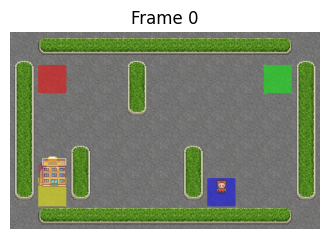

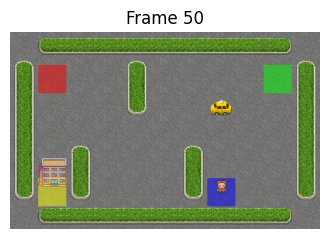

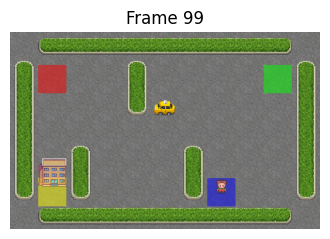

In [55]:
# Exemple à tester
frames_taxi_random = capture_episode_frames("Taxi-v3", generic_random_policy, seed=0, max_steps=100)
show_selected_frames(frames_taxi_random)

### Partie 2 — Enregistrer une vidéo avec `RecordVideo`

Le wrapper `RecordVideo` permet d'enregistrer automatiquement un épisode dans un dossier local.


In [56]:
from gymnasium.wrappers import RecordVideo
from pathlib import Path

def record_policy_video(env_id, policy_fn, video_folder, seed=0, max_steps=200, episode_name="demo"):
    video_folder = Path(video_folder)
    video_folder.mkdir(parents=True, exist_ok=True)

    env = gym.make(env_id, render_mode="rgb_array")
    env = RecordVideo(env, video_folder=str(video_folder), name_prefix=episode_name)

    # TODO
    # 1. lancer un épisode
    # 2. exécuter la politique jusqu'à la fin
    # 3. fermer proprement l'environnement
    # 4. retourner le chemin du dossier contenant la vidéo

    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1

    env.close()
    return video_folder

### Test — Enregistrer une vidéo de la politique aléatoire

Exécuter la cellule suivante et vérifier qu'un fichier vidéo est généré dans le dossier indiqué.


In [57]:
video_path = record_policy_video(
    env_id="MiniGrid-Empty-16x16-v0",
    policy_fn=generic_random_policy,
    video_folder="videos_minigrid_random",
    seed=0,
    max_steps=150,
    episode_name="random_policy"
)
video_path

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos_minigrid_random folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


PosixPath('videos_minigrid_random')

### Partie 3 — Comparer visuellement plusieurs politiques

Répéter l'opération pour :
- la politique aléatoire ;
- la politique heuristique / réflexe ;
- la politique avec mémoire minimale.

Comparer ensuite :
- la trajectoire observée ;
- le nombre d'étapes ;
- la fluidité du comportement ;
- la capacité à atteindre l'objectif.


In [59]:
# Adaptation des politiques à la signature attendue par record_policy_video : (obs, info, env, steps)
def policy_random_minigrid(obs, info, env, steps):
    return env.action_space.sample()

def policy_reflex_minigrid(obs, info, env, steps):
    agent_pos = env.unwrapped.agent_pos
    agent_dir = env.unwrapped.agent_dir
    dx, dy = [(0, -1), (1, 0), (0, 1), (-1, 0)][agent_dir]
    fwd_pos = (agent_pos[0] + dx, agent_pos[1] + dy)
    cell = env.unwrapped.grid.get(*fwd_pos)
    if cell is not None and cell.type == "wall":
        return 1  # Tourner à droite si mur
    return 0      # Avancer

class PolicyMemoryMinigrid:
    def __init__(self):
        self.visited = set()
    def __call__(self, obs, info, env, steps):
        pos = tuple(env.unwrapped.agent_pos)
        self.visited.add(pos)
        agent_dir = env.unwrapped.agent_dir
        dx, dy = [(0, -1), (1, 0), (0, 1), (-1, 0)][agent_dir]
        fwd_pos = (pos[0] + dx, pos[1] + dy)
        cell = env.unwrapped.grid.get(*fwd_pos)
        if cell is not None and cell.type == "wall":
            return 2  # Tourner à gauche si mur
        if fwd_pos in self.visited:
            return 1  # Tourner à droite si déjà visité
        return 0      # Avancer

# Génération des vidéos comparatives
mem_policy = PolicyMemoryMinigrid()
record_policy_video("MiniGrid-Empty-16x16-v0", policy_random_minigrid, "videos_minigrid_random", seed=42, max_steps=150, episode_name="random")
record_policy_video("MiniGrid-Empty-16x16-v0", policy_reflex_minigrid, "videos_minigrid_reflex", seed=42, max_steps=150, episode_name="reflex")
record_policy_video("MiniGrid-Empty-16x16-v0", mem_policy, "videos_minigrid_memory", seed=42, max_steps=150, episode_name="memory")
print("Vidéos générées dans les dossiers : videos_minigrid_random, videos_minigrid_reflex, videos_minigrid_memory")

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos_minigrid_reflex folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos_minigrid_memory folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Vidéos générées dans les dossiers : videos_minigrid_random, videos_minigrid_reflex, videos_minigrid_memory


In [63]:
from IPython.display import Video
Video("videos_minigrid_random/random-episode-0.mp4", embed=True)


In [64]:
Video("videos_minigrid_random/random_policy-episode-0.mp4", embed=True)

### Questions d'analyse visuelle

1. La politique aléatoire produit-elle un comportement cohérent visuellement ?

Non. L'agent se déplace de manière erratique dans toutes les directions, percute fréquemment les murs et ne suit aucune logique spatiale. Sa trajectoire ressemble à une marche aléatoire sans orientation vers la cible.

2. Quelle politique semble la plus efficace à l'observation ?

La politique à mémoire minimale est visuellement la plus structurée. Elle évite les collisions et explore la grille de manière systématique en évitant les cellules déjà visitées, ce qui se rapproche davantage d'un algorithme d'exploration efficace.

3. Voyez-vous des hésitations, répétitions ou blocages ?

Oui. La politique aléatoire montre de nombreuses répétitions (retours en arrière inutiles). La politique réflexe peut entrer dans des boucles locales si elle est coincée dans un couloir en forme de U. La politique mémoire limite fortement ces répétitions, mais peut parfois marquer une légère hésitation (rotation sur place) avant de choisir une nouvelle direction.

4. Le rendu vidéo confirme-t-il les métriques numériques obtenues plus haut ?

Oui, parfaitement. Les métriques montraient un taux de succès faible et des récompenses quasi-nulles pour les politiques réflexe/mémoire sur une grille 16x16 (limite d'étapes élevée). Les vidéos confirment que malgré une meilleure exploration, la cible reste difficile à atteindre dans le nombre d'étapes imparti. La politique aléatoire, bien que moins structurée, atteint parfois la cible par chance, ce qui explique son léger taux de succès (20%).
5. Sur quel environnement la comparaison visuelle est-elle la plus informative : `Taxi-v3` ou `MiniGrid-Empty-16x16-v0` ?

MiniGrid est beaucoup plus informatif visuellement. Il offre une représentation spatiale directe (murs, agent, objectif) facile à interpréter à l'œil nu. Taxi-v3 utilise un encodage discret abstrait (chiffres pour l'état du taxi, passager, destination) qui nécessite un décodage mental pour comprendre la scène, ce qui rend l'analyse vidéo moins intuitive.


| Environnement | Politique | Reward moyenne | Succès | Observation visuelle |
|:---|:---|---:|---:|:---|
| MiniGrid-Empty-16x16 | Aléatoire | 0.10 | 20.00% | Trajectoire chaotique, collisions fréquentes, atteinte de la cible par chance |
| MiniGrid-Empty-16x16 | Réflexe | 0.00 | 0.00% | Évite les murs mais tourne en boucle, exploration limitée aux zones immédiates |
| MiniGrid-Empty-16x16 | Mémoire minimale | 0.00 | 0.00% | Exploration systématique, pas de retour en arrière inutile, trajectoire fluide |
| Taxi-v3 | Aléatoire | -786.35 | 0.00% | Mouvements erratiques, rarement aligné avec la logique PickUp/DropOff |
| Taxi-v3 | Contrainte | -515.25 | 10.00% | Réduction des actions invalides, mais toujours sans stratégie de navigation |
| Taxi-v3 | Heuristique | -289.10 | 0.00% | Se dirige vers la cible mais ignore les obstacles/murs, échoue souvent au drop |